# 2.2 神经网络的数据表示

In [ ]:
# 前面的数据存储在多维 Numpy 数组中，也叫张量（tensor0），张量的维度（dimension）通常叫做轴（axis） 

## 2.2.1 标量（0D 张量）

In [1]:
# 仅包含一个数字的张量叫做标量（scalar），在 Numpy 中一个 float32 或 float64 的数字是一个标量张量
# 可以用 ndim 来查看一个 Numpy 张量的轴的个数（0 轴即 ndim == 0），张量轴的个数称为阶（rank）
import numpy as np
x = np.array(12)
x

array(12)

In [2]:
x.ndim

0

## 2.2.2 向量（1D 张量）

In [3]:
# 数字组成的数组叫做向量（vector）或一维张量（1D 张量）
# 这个向量有5个元素，称为 5D 向量
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [4]:
x.ndim

1

## 2.2.3 矩阵（2D 张量）

In [8]:
# 向量组成的数组叫做矩阵（matrix）或二维张量（2D 张量），矩阵有 2 个轴（行和列）
# 第一个轴上的元素叫做行（row），[5, 78, 2, 34, 0]
# 第二个轴上的元素叫做列（column），[5，6, 7]
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x

array([[ 5, 78,  2, 34,  0],
       [ 6, 79,  3, 35,  1],
       [ 7, 80,  4, 36,  2]])

In [9]:
x.ndim

2

## 2.2.4 3D 张量与更高维张量

In [11]:
# 将多个矩阵组成一个新的数组，可以得到一个 3D 张量，即数字的立方体
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

3

## 2.2.5 关键属性

In [13]:
# 张量是由以下三个关键属性定义的:
#    轴的个数（阶）：Numpy 的张量叫 ndim
#    形状：表示张量沿每个轴的维度大小（元素个数）
#    数据类型：Python 中叫 dtype，可以有 float32、uint8、float64
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "0"

from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(train_images.ndim, train_images.shape, train_images.dtype)

3 (60000, 28, 28) uint8


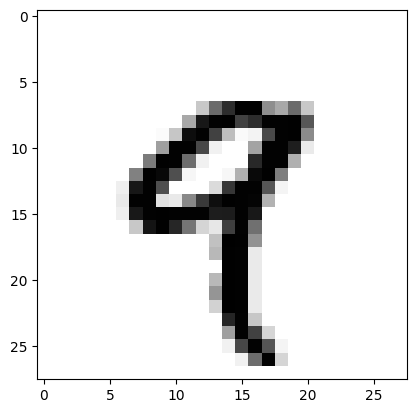

In [16]:
# 每个矩阵由 28 X 28 个整数组成，则每个都是一张灰度图像，元素的取值范围 0~255
# 可以使用 matplotlib 来显示这个 3D 张量中的第 4 个数字
digit = train_images[4]

import matplotlib.pyplot as plt
# cmap=plt.cm.binary 的意思是：用黑白颜色映射来显示这张图像
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

## 2.2.6 Numpy 中操作张量

In [19]:
# 选择张量的特定元素叫做张量切片（tensor slicing）
my_slice = train_images[10:100]
print(my_slice.shape)

(90, 28, 28)


In [20]:
# 上面的等同写法
my_slice = train_images[10:100, :, :]
print(my_slice.shape)

(90, 28, 28)


In [21]:
# 另一种等同写法
my_slice = train_images[10:100, 0:28, 0:28]
print(my_slice.shape)

(90, 28, 28)


In [22]:
# 在所有图像的右下角选择 14 * 14 像素的区域
my_slice = train_images[:, 14:, 14:]
print(my_slice.shape)

(60000, 14, 14)


In [23]:
# 裁剪出中心 14 * 14 像素的区域
my_slice = train_images[:, 7:-7, 7:-7]
print(my_slice.shape)

(60000, 14, 14)


## 2.2.7 数据批量概念

In [27]:
# 深度学习不会同时处理整个数据集，而是将数据拆分成小批量，如批量大小 128
batch = train_images[:128]

In [28]:
batch = train_images[128:256]

## 2.2.8 现实世界中的数据张量

In [ ]:
# 向量数据：2D 张量
    (samples, features)
# 时间序列数据或序列数据： 3D 张量
    (samples, timesteps, features)
# 图像：4D 张量
    (samples, height, width, channels)          # TensorFlow 写法
    (samples, channels, height, width)          # Theano 写法
# 视频： 5D 张量
    (samples, frames, height, width, channels)
    (samples, frames, channels, height, width)